In [62]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from tqdm import tqdm
import matplotlib.pyplot as plt
from num2words import num2words

## Dataset

In [2]:
DEVICE = "mps"
BATCH_SIZE = 64

MAX_N = 999
TEST_HOLDOUT = 100  # number of numbers !
ALL_NUMBERS = torch.randperm(MAX_N + 1)
TRAIN_NUMBERS = ALL_NUMBERS[:-TEST_HOLDOUT]
TEST_NUMBERS = ALL_NUMBERS[-TEST_HOLDOUT:]

SOS = "<"
EOS = ">"
PAD = "_"
tokens = (
    [SOS, EOS, PAD]
    + [str(i) for i in range(10)]
    + [chr(ord("a") + i) for i in range(26)]
    + [" ", "-"]
)
c2i = {c: i for i, c in enumerate(tokens)}
i2c = {i: c for c, i in c2i.items()}

VOCAB_SIZE = len(tokens)

In [9]:
# let's change this to have a real test set. so we hold out some numbers

class Num2wordsDataset(Dataset):

    def __init__(self, test: bool = False, epoch_size: int = 1024, max_n: int = 999):
        self.test = test
        self.epoch_size = epoch_size
        self.max_n = max_n

    def __len__(self):
        return self.epoch_size

    def _generate_one(self):
        if self.test:
            numbers = TEST_NUMBERS
        else:
            numbers = TRAIN_NUMBERS
        idx = torch.randint(0, len(numbers), (1,)).item()
        num = numbers[idx].item()
        word = num2words(num)
        x = torch.tensor([c2i[c] for c in str(num)])
        y = torch.tensor([c2i[c] for c in SOS + word + EOS])
        return x, y
    
    def _prepare_one(self, num: int):
        word = num2words(num)
        x = torch.tensor([c2i[c] for c in str(num)])
        y = torch.tensor([c2i[c] for c in SOS + word + EOS])
        return x, y

    def __getitem__(self, _):
        return self._generate_one()


def right_pad_seqs(batch):
    x, y = zip(*batch)
    x_lens = torch.tensor([len(s) for s in x])
    x_padded = pad_sequence(x, batch_first=True, padding_value=c2i[PAD])
    y_padded = pad_sequence(y, batch_first=True, padding_value=c2i[PAD])
    return x_padded, x_lens, y_padded


ds_train = Num2wordsDataset(test=False)
ds_test = Num2wordsDataset(test=True)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, collate_fn=right_pad_seqs)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, collate_fn=right_pad_seqs)

## Model

In [4]:

class Encoder(nn.Module):
    def __init__(self, n_layer: int, n_hidden: int, embedding_size: int = 8):
        super().__init__()
        self.embedding_size = embedding_size
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=n_hidden,
            num_layers=n_layer,
            batch_first=True,
        )

    def forward(self, x, x_lens) -> torch.Tensor:
        embedded = self.emb(x)
        packed = pack_padded_sequence(
            embedded,
            x_lens,
            batch_first=True,
            enforce_sorted=False,
        )
        out, (h_n, c_n) = self.lstm(packed)
        return h_n, c_n  # we want the hidden, cell state


class Decoder(nn.Module):
    def __init__(self, n_layer: int, n_hidden: int, embedding_size: int = 8):
        super().__init__()
        self.embedding_size = embedding_size
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=n_hidden,
            num_layers=n_layer,
            batch_first=True,
        )
        self.fc = nn.Linear(n_hidden, VOCAB_SIZE)

    def forward(self, x, h_n, c_n) -> torch.Tensor:
        x = x.unsqueeze(1)
        embedded = self.emb(x)
        out, (h_n, c_n) = self.lstm.forward(embedded, (h_n, c_n))
        out = self.fc(out.squeeze(1))
        return out, (h_n, c_n)


class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lens, target=None, max_len=32):
        """if trg is not None then we do teacher forcing"""
        batch_size = src.shape[0]

        h_n, c_n = self.encoder(src, src_lens)
        x = torch.full((batch_size,), c2i[SOS], dtype=src.dtype).to(self.device)

        output = []
        if target is not None:
            max_t = target.shape[-1] - 1
        else:
            max_t = max_len
        for t in range(max_t):
            out, (h_n, c_n) = self.decoder(x, h_n, c_n)
            output.append(out)

            # update next input based on teacher forcing
            if target is not None:
                x = target[:, t + 1]
            else:
                x = out.argmax(dim=-1)

        output = torch.stack(output, dim=1)
        return output

## Train ??

In [5]:
def get_test_loss(model, dl_test, teacher_forcing: bool = True):
    loss_fn = nn.CrossEntropyLoss(ignore_index=c2i[PAD])
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, x_lens, y in dl_test:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            if teacher_forcing:
                y_pred = model.forward(x, x_lens, y)
            else:
                y_pred = model.forward(x, x_lens)
            # flatten over B, T
            y_pred = y_pred.flatten(0, 1)
            y = y[:, 1:].flatten(0, 1)
            
            
            loss = loss_fn(y_pred, y)
            total_loss += loss * x.size(0)
    avg_loss = (total_loss / len(dl_test.dataset)).item()
    return avg_loss

def train(
    model: nn.Module, dl_train: DataLoader, dl_test: DataLoader, n_epochs: int = 10
):
    optim = torch.optim.AdamW(params=model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss(ignore_index=c2i[PAD])
    pbar = tqdm(range(n_epochs))

    model.train()
    train_losses = []
    test_losses = []
    for _ in pbar:
        total_loss = 0
        for x, x_lens, y in dl_train:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optim.zero_grad()
            y_pred = model(x, x_lens, y)

            # flatten over B, T
            y_pred = y_pred.flatten(0, 1)
            y = y[:, 1:].flatten(0, 1)

            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()
            
            total_loss += loss.detach() * x.size(0)
        avg_loss = (total_loss / len(dl_train.dataset)).item()
        train_losses.append(avg_loss)
        test_loss = get_test_loss(model, dl_test)
        test_losses.append(test_loss)
        pbar.set_postfix({"Train loss": avg_loss})
    
    return train_losses, test_losses

100%|██████████| 200/200 [01:43<00:00,  1.92it/s, Train loss=0.000975]


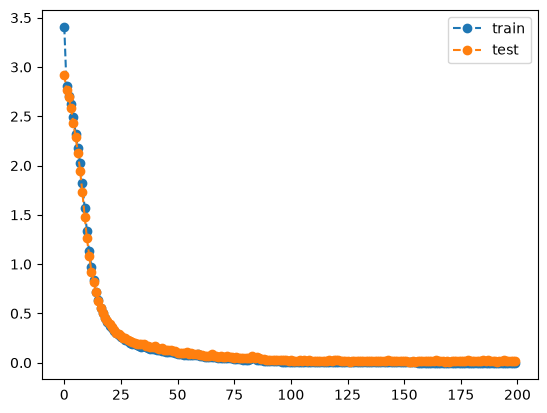

In [6]:
encoder = Encoder(2, 128).to(DEVICE)
decoder = Decoder(2, 128).to(DEVICE)
model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
train_losses, test_losses = train(model, dl_train, dl_test, n_epochs=200)
plt.plot(train_losses, "--o", label="train")
plt.plot(test_losses, "--o", label="test")
plt.legend()
plt.show()

In [11]:
model.eval()
for _ in range(10):
    x, y = ds_test._generate_one()
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    x_len = torch.tensor([len(x)])
    y_pred = model.forward(x.unsqueeze(0), x_len).squeeze().detach().cpu()
    preds = y_pred.argmax(dim=1)
    if c2i[EOS] in preds:
        eos_idx = ((preds == c2i[EOS]) * 1).argmax()
        preds = preds[:eos_idx]
    x_str = ''.join([i2c[i.item()] for i in x])
    print(x_str + ' | ' + ''.join([i2c[i.item()] for i in preds]))

701 | seven hundred and one
963 | nine hundred and sixty-three
855 | eight hundred and fifty-five
681 | six hundred and eighty-one
247 | two hundred and forty-seven
25 | twenty-five
913 | nine hundred and thirteen
375 | three hundred and seventy-five
66 | sixty-six
159 | one hundred and fifty-nine


In [44]:
# let's do it exhaustively
model.eval()
correct_count = 0
for num in TEST_NUMBERS:
    x, y = ds_test._prepare_one(num.item())
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    x_len = torch.tensor([len(x)])
    y_pred = model.forward(x.unsqueeze(0), x_len).squeeze().detach().cpu()
    preds = y_pred.argmax(dim=1)
    if c2i[EOS] in preds:
        eos_idx = ((preds == c2i[EOS]) * 1).argmax()
        preds = preds[:eos_idx]

    y = y.to("cpu")
    # if len is right and all chars are right
    if len(y) == len(preds) + 2 and torch.all(y[1:-1].to("cpu") == preds).item():
        correct_count += 1
    else: # incorrect, print
        x_str = "".join([i2c[i.item()] for i in x])
        print(x_str + " | " + "".join([i2c[i.item()] for i in preds]))

print(f'{correct_count/len(TEST_NUMBERS):.2%}')

8 | twenty
16 | seventy
11 | tne
97.00%


```
8 | twenty
16 | seventy
11 | tne
97.00%
```

We see small number of failures on 'unique' small numbers

## Attention

now let's try same problem but add attention. make sure it all works

In [68]:
D3 = 16


class AdditiveAttention(nn.Module):
    """
    e_i = v^t tanh(W_1 h_i + W_2 s)

        - W_1 \in R^(d_3 x d_1)
        - W_2 \in R^(d_3 x d_2)
        - v \in R^(d_3)
    """

    def __init__(self, d1, d2, d3=D3):
        super().__init__()
        self.W1 = nn.Linear(d1, d3)
        self.W2 = nn.Linear(d2, d3)
        self.v = nn.Linear(d3, 1)

    def forward(self, s_t, h, src_mask):
        """s_t is decoder hidden state, h is all encoder outputs
        s_t is (B, H)
        h is (B, N, H)
        src_mask is (B, N)
        """
        keys = self.W1(h)  # (B, N, D3)
        query = self.W2(s_t).unsqueeze(1)  # (B, 1, D3)

        scores = self.v(torch.tanh(query + keys))  # (B, N, 1)

        # now apply the masking
        scores = scores.masked_fill(~src_mask.unsqueeze(-1), float("-inf"))

        alpha = torch.softmax(scores, dim=1)  # (B, N, 1)

        a = torch.bmm(alpha.transpose(1, 2), h)  # (B, 1, H)

        return a, alpha


class EncoderAttn(nn.Module):
    def __init__(self, n_layer: int, n_hidden: int, embedding_size: int = 8):
        super().__init__()
        self.embedding_size = embedding_size
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=n_hidden,
            num_layers=n_layer,
            batch_first=True,
        )

    def forward(self, x, x_lens) -> torch.Tensor:
        embedded = self.emb(x)
        packed = pack_padded_sequence(
            embedded,
            x_lens,
            batch_first=True,
            enforce_sorted=False,
        )
        out, (h_n, c_n) = self.lstm(packed)
        # need to pad for attn
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        return out, h_n, c_n  # we now need out as well


class DecoderAttn(nn.Module):
    def __init__(self, n_layer: int, n_hidden: int, embedding_size: int = 8):
        super().__init__()
        self.embedding_size = embedding_size
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)
        self.lstm = nn.LSTM(
            input_size=embedding_size + n_hidden,
            hidden_size=n_hidden,
            num_layers=n_layer,
            batch_first=True,
        )
        self.fc = nn.Linear(n_hidden, VOCAB_SIZE)
        self.attention = AdditiveAttention(d1=n_hidden, d2=n_hidden, d3=D3)

    def forward(self, x, h_n, c_n, h, src_mask) -> torch.Tensor:
        # h is encoder output
        x = x.unsqueeze(1)
        embedded = self.emb(x)
        a, alpha = self.attention.forward(h_n[-1], h, src_mask)
        lstm_input = torch.cat((embedded, a), dim=2)
        out, (h_n, c_n) = self.lstm.forward(lstm_input, (h_n, c_n))
        out = self.fc(out.squeeze(1))
        return out, (h_n, c_n), alpha


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self, src, src_lens, target=None, max_len=32, return_alphas: bool = False
    ):
        """if trg is not None then we do teacher forcing"""
        batch_size = src.shape[0]

        enc_out, h_n, c_n = self.encoder(src, src_lens)
        src_mask = src != c2i[PAD]  # (B, N)
        x = torch.full((batch_size,), c2i[SOS], dtype=src.dtype).to(self.device)

        output = []
        alphas = []
        if target is not None:
            max_t = target.shape[-1] - 1
        else:
            max_t = max_len
        for t in range(max_t):
            out, (h_n, c_n), alpha = self.decoder(x, h_n, c_n, enc_out, src_mask)
            output.append(out)
            alphas.append(alpha)

            # update next input based on teacher forcing
            if target is not None:
                x = target[:, t + 1]
            else:
                x = out.argmax(dim=-1)

        output = torch.stack(output, dim=1)
        if not return_alphas:
            return output
        alphas = torch.stack(alphas, dim=1)
        return output, alphas

<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
/var/folders/wf/jmjdzyf11pb4lsl77jc423840000gn/T/ipykernel_14000/1906066139.py:5: SyntaxWarning: invalid escape sequence '\i'
  """


100%|██████████| 200/200 [02:55<00:00,  1.14it/s, Train loss=0.000991]


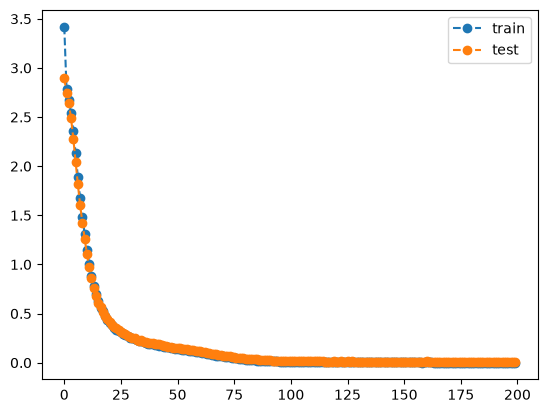

In [69]:
encoder_attn = EncoderAttn(2, 128).to(DEVICE)
decoder_attn = DecoderAttn(2, 128).to(DEVICE)
model_attn = Seq2SeqAttn(encoder_attn, decoder_attn, DEVICE).to(DEVICE)
train_losses, test_losses = train(model_attn, dl_train, dl_test, n_epochs=200)
plt.plot(train_losses, "--o", label="train")
plt.plot(test_losses, "--o", label="test")
plt.legend()
plt.show()

In [70]:
# let's do it exhaustively
model_attn.eval()
correct_count = 0
for num in TEST_NUMBERS:
    x, y = ds_test._prepare_one(num.item())
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    x_len = torch.tensor([len(x)])
    y_pred = model_attn.forward(x.unsqueeze(0), x_len).squeeze().detach().cpu()
    preds = y_pred.argmax(dim=1)
    if c2i[EOS] in preds:
        eos_idx = ((preds == c2i[EOS]) * 1).argmax()
        preds = preds[:eos_idx]

    y = y.to("cpu")
    # if len is right and all chars are right
    if len(y) == len(preds) + 2 and torch.all(y[1:-1].to("cpu") == preds).item():
        correct_count += 1
    else: # incorrect, print
        x_str = "".join([i2c[i.item()] for i in x])
        print(x_str + " | " + "".join([i2c[i.item()] for i in preds]))

print(f'{correct_count/len(TEST_NUMBERS):.2%}')

11 | thirteen
99.00%


### alpha inspection

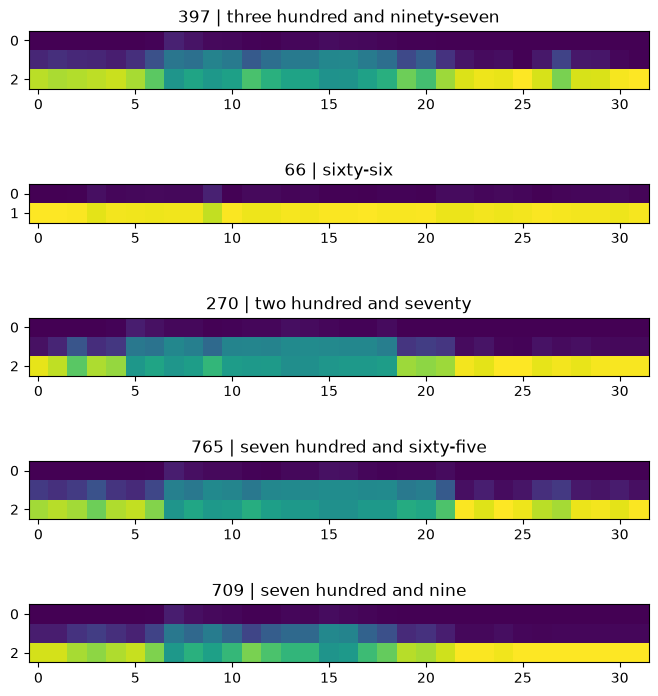

In [85]:
model_attn.eval()
fig, axs = plt.subplots(5)
fig.set_size_inches(8, 9)
for i in range(5):
    x, y = ds_test._generate_one()
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    x_len = torch.tensor([len(x)])
    y_pred, alphas = model_attn.forward(x.unsqueeze(0), x_len, return_alphas=True)
    y_pred = y_pred.squeeze().detach().cpu()
    preds = y_pred.argmax(dim=1)
    if c2i[EOS] in preds:
        eos_idx = ((preds == c2i[EOS]) * 1).argmax()
        preds = preds[:eos_idx]
    x_str = "".join([i2c[i.item()] for i in x])
    title = x_str + " | " + "".join([i2c[i.item()] for i in preds])
    axs[i].imshow(alphas.squeeze().cpu().detach().T)
    axs[i].set_title(title)